In [1]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import shutil
import random

SOURCE_DIR = "/content/drive/MyDrive/Dataset/PlantVillage"
BASE_DIR = "/content/PlantVillage_split"

TRAIN_DIR = BASE_DIR + "/train"
VAL_DIR = BASE_DIR + "/valid"
TEST_DIR = BASE_DIR + "/test"

# Create folders
for folder in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    os.makedirs(folder, exist_ok=True)

# Split ratio
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Loop through each class
for class_name in os.listdir(SOURCE_DIR):
    class_path = os.path.join(SOURCE_DIR, class_name)

    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        random.shuffle(images)

        total = len(images)
        train_end = int(total * train_ratio)
        val_end = int(total * (train_ratio + val_ratio))

        train_imgs = images[:train_end]
        val_imgs = images[train_end:val_end]
        test_imgs = images[val_end:]

        # Create class folders
        for split, split_imgs in zip(
            [TRAIN_DIR, VAL_DIR, TEST_DIR],
            [train_imgs, val_imgs, test_imgs]
        ):
            os.makedirs(os.path.join(split, class_name), exist_ok=True)

            for img in split_imgs:
                src = os.path.join(class_path, img)
                dst = os.path.join(split, class_name, img)
                shutil.copy(src, dst)

print("Dataset split completed!")

Dataset split completed!


In [145]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [146]:
import typing_extensions
import IPython


#print("typing_extensions:", typing_extensions.__version__)
print("IPython:", IPython.__version__)
print("tf.keras exists:", hasattr(tf, "keras"))

IPython: 7.34.0
tf.keras exists: True


In [147]:
import tensorflow as tf
import matplotlib.pyplot as plt #for visualization
import pandas as pd
import seaborn as sns #for data visualization

In [148]:
training_set=tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 14478 files belonging to 15 classes.


In [149]:
validation_set=tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,

)

Found 3105 files belonging to 15 classes.


In [150]:

test_set=tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,

)

Found 3108 files belonging to 15 classes.


In [151]:
training_set = training_set.map(lambda x,y: (x/255.0, y))
validation_set = validation_set.map(lambda x,y: (x/255.0, y))
test_set = test_set.map(lambda x,y: (x/255.0, y))

In [152]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[0.46960783 0.422549   0.43823528]
   [0.51960784 0.47254902 0.4882353 ]
   [0.45490196 0.40784314 0.42352942]
   ...
   [0.5715686  0.5362745  0.55588233]
   [0.55       0.5147059  0.53431374]
   [0.54901963 0.5137255  0.53333336]]

  [[0.4392157  0.39215687 0.40784314]
   [0.4509804  0.40392157 0.41960785]
   [0.3852941  0.3382353  0.35392156]
   ...
   [0.50784314 0.47254902 0.49215686]
   [0.47843137 0.44313726 0.4627451 ]
   [0.5372549  0.5019608  0.52156866]]

  [[0.422549   0.3754902  0.39117646]
   [0.40098038 0.35392156 0.36960784]
   [0.52843136 0.48137254 0.4970588 ]
   ...
   [0.5362745  0.5009804  0.5205882 ]
   [0.55196077 0.51666665 0.5362745 ]
   [0.53137255 0.49607843 0.5156863 ]]

  ...

  [[0.5088235  0.46960783 0.5009804 ]
   [0.53039217 0.49117646 0.52254903]
   [0.30882353 0.26960784 0.3009804 ]
   ...
   [0.57058823 0.5470588  0.5862745 ]
   [0.4764706  0.45294118 0.49215686]
   [0.5901961  0.56666666 0.60588235]]

  [[0.52156866 0.48235294 0.513725

In [153]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential

In [154]:
base_model = MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

In [155]:
base_model.trainable = False  # very important

In [156]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(15, activation='softmax')
])

In [157]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [158]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [159]:
training_history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=10
)

Epoch 1/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 37s 62ms/step - accuracy: 0.5219 - loss: 1.5725 - val_accuracy: 0.7401 - val_loss: 0.8866
Epoch 2/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.7309 - loss: 0.8605 - val_accuracy: 0.8058 - val_loss: 0.6376
Epoch 3/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.7856 - loss: 0.6730 - val_accuracy: 0.8354 - val_loss: 0.5345
Epoch 4/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.8190 - loss: 0.5699 - val_accuracy: 0.8557 - val_loss: 0.4607
Epoch 5/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.8440 - loss: 0.4990 - val_accuracy: 0.8747 - val_loss: 0.4152
Epoch 6/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.8571 - loss: 0.4481 - val_accuracy: 0.8821 - val_loss: 0.3861
Epoch 7/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.8752 - loss: 0.4049 - val_accuracy: 0.8895 - val_loss: 0.3590
Epoch 8/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.8819 - loss: 0.3713 - 

In [160]:
#model evaluation on training set
train_loss,train_acc=model.evaluate(training_set)

453/453 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9347 - loss: 0.2287


In [161]:
print("Training Accuracy:",train_acc)
print("Training Loss:",train_loss)

Training Accuracy: 0.9347285628318787
Training Loss: 0.22869551181793213


In [162]:
#model evaluation on validation set
val_loss,val_acc=model.evaluate(validation_set)

98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9002 - loss: 0.3172


In [163]:
print("Validation Accuracy:",val_acc)
print("Validation Loss:",val_loss)

Validation Accuracy: 0.9001610279083252
Validation Loss: 0.3172205090522766


In [164]:
# model evaluation on test set
test_loss, test_acc = model.evaluate(test_set)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8948 - loss: 0.3305
Test Accuracy: 0.8947876691818237
Test Loss: 0.33050698041915894


In [165]:
model.save('Trained_Plant_Disease_Prediction.h5')

In [166]:
model.save('Trained_Plant_Disease_Prediction.keras')

In [193]:
model.save('/content/drive/MyDrive/Trained_Plant_Model.keras')

In [194]:
model.save('/content/drive/MyDrive/model.h5')

In [198]:
model.save_weights('/content/drive/MyDrive/model.weights.h5')

In [167]:
training_history.history

{'accuracy': [0.5218952894210815,
  0.7309020757675171,
  0.7856057286262512,
  0.8190357685089111,
  0.844039261341095,
  0.8570935130119324,
  0.8751899600028992,
  0.8818897604942322,
  0.8897637724876404,
  0.9000552296638489],
 'loss': [1.5724586248397827,
  0.8605380058288574,
  0.6729625463485718,
  0.5698725581169128,
  0.49903926253318787,
  0.4481402635574341,
  0.40489131212234497,
  0.3712739050388336,
  0.34706661105155945,
  0.3207418918609619],
 'val_accuracy': [0.7400966286659241,
  0.8057971000671387,
  0.8354267477989197,
  0.8557165861129761,
  0.874718189239502,
  0.8821256160736084,
  0.8895329833030701,
  0.8937197923660278,
  0.898228645324707,
  0.9001610279083252],
 'val_loss': [0.8866109251976013,
  0.6376381516456604,
  0.5344887971878052,
  0.4607487618923187,
  0.4152316153049469,
  0.38609007000923157,
  0.3589884638786316,
  0.34237557649612427,
  0.32576432824134827,
  0.3172203600406647]}

In [168]:

#Recording the history in json
import json
with open('training_history.json', 'w') as f:
    json.dump(training_history.history, f)

In [169]:
training_history.history['val_accuracy']

[0.7400966286659241,
 0.8057971000671387,
 0.8354267477989197,
 0.8557165861129761,
 0.874718189239502,
 0.8821256160736084,
 0.8895329833030701,
 0.8937197923660278,
 0.898228645324707,
 0.9001610279083252]

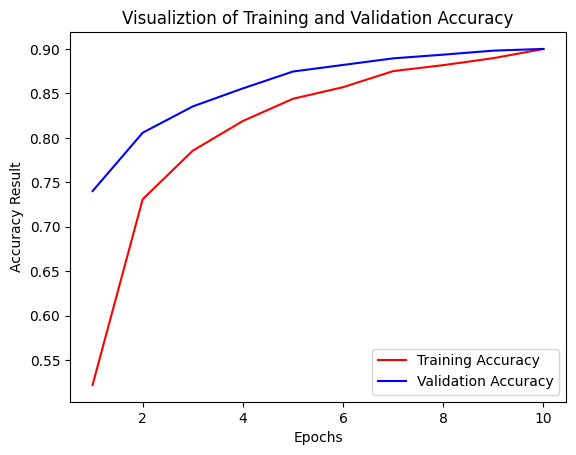

In [170]:
epochs=[i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Result')
plt.title('Visualiztion of Training and Validation Accuracy')
plt.legend()
plt.show()

In [171]:
class_names

['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [172]:

test_set=tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,

)

Found 3108 files belonging to 15 classes.


In [173]:
y_pred=model.predict(test_set)
y_pred,y_pred.shape

98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step


(array([[6.2957928e-02, 1.4989975e-01, 5.6406859e-02, ..., 2.9742976e-05,
         2.1843158e-03, 9.7373106e-02],
        [1.5149380e-02, 3.8015921e-02, 1.2901925e-02, ..., 1.4905402e-05,
         6.3542370e-04, 6.2436342e-02],
        [7.0930719e-02, 1.4032258e-01, 1.5156230e-01, ..., 7.5444818e-04,
         1.3114851e-02, 1.6453700e-01],
        ...,
        [9.3638182e-02, 2.6032835e-01, 3.7613802e-02, ..., 4.6489880e-05,
         2.6585890e-03, 3.5287540e-02],
        [1.9136779e-01, 2.0809220e-01, 1.2671971e-01, ..., 5.4996595e-05,
         3.7051840e-03, 5.3644311e-02],
        [2.9768188e-02, 2.0632593e-02, 1.4194983e-02, ..., 2.4233905e-05,
         6.4085599e-04, 5.1583834e-02]], dtype=float32),
 (3108, 15))

In [174]:
predicted_categories=tf.argmax(y_pred,axis=1)
predicted_categories

<tf.Tensor: shape=(3108,), dtype=int64, numpy=array([6, 6, 9, ..., 6, 1, 6])>

In [175]:
true_categories=tf.concat([y for x, y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(3108, 15), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [176]:
y_true=tf.argmax(true_categories,axis=1)
y_true

<tf.Tensor: shape=(3108,), dtype=int64, numpy=array([ 0,  0,  0, ..., 14, 14, 14])>

In [177]:
from sklearn.metrics import classification_report,confusion_matrix

In [178]:
print(classification_report(y_true,predicted_categories,target_names=class_names))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.00      0.00      0.00       152
                     Pepper__bell___healthy       0.14      0.83      0.24       222
                      Potato___Early_blight       0.49      0.15      0.23       150
                       Potato___Late_blight       0.00      0.00      0.00       150
                           Potato___healthy       0.00      0.00      0.00        23
                      Tomato_Bacterial_spot       0.00      0.00      0.00       320
                        Tomato_Early_blight       0.06      0.55      0.11       150
                         Tomato_Late_blight       0.82      0.03      0.06       287
                           Tomato_Leaf_Mold       0.00      0.00      0.00       145
                  Tomato_Septoria_leaf_spot       0.15      0.21      0.18       266
Tomato_Spider_mites_Two_spotted_spider_mite       0.00      0.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [179]:
cm=confusion_matrix(y_true,predicted_categories)
cm.shape
cm

array([[  0,  70,   3,   0,   1,   0,  67,   0,   0,  11,   0,   0,   0,
          0,   0],
       [  0, 185,   2,   0,   0,   0,  32,   0,   0,   2,   0,   0,   0,
          0,   1],
       [  0, 103,  22,   0,   0,   0,  17,   0,   0,   7,   0,   0,   0,
          0,   1],
       [  0,  60,   4,   0,   0,   0,  63,   0,   0,  20,   0,   0,   0,
          0,   3],
       [  0,  20,   0,   0,   0,   0,   3,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  2, 226,   0,   0,   0,   0,  76,   0,   0,  15,   0,   0,   0,
          0,   1],
       [  0,  44,   0,   0,   0,   0,  83,   0,   0,  21,   0,   0,   0,
          0,   2],
       [ 11,  74,   2,   0,   0,   0, 136,   9,   0,  53,   0,   0,   0,
          0,   2],
       [  1,  19,   3,   0,   0,   0,  72,   0,   0,  49,   0,   0,   0,
          0,   1],
       [  0,  86,   2,   0,   2,   0, 117,   1,   0,  55,   0,   0,   0,
          0,   3],
       [  0,  85,   0,   0,   0,   0, 148,   0,   0,  12,   0,   0,   0,
       

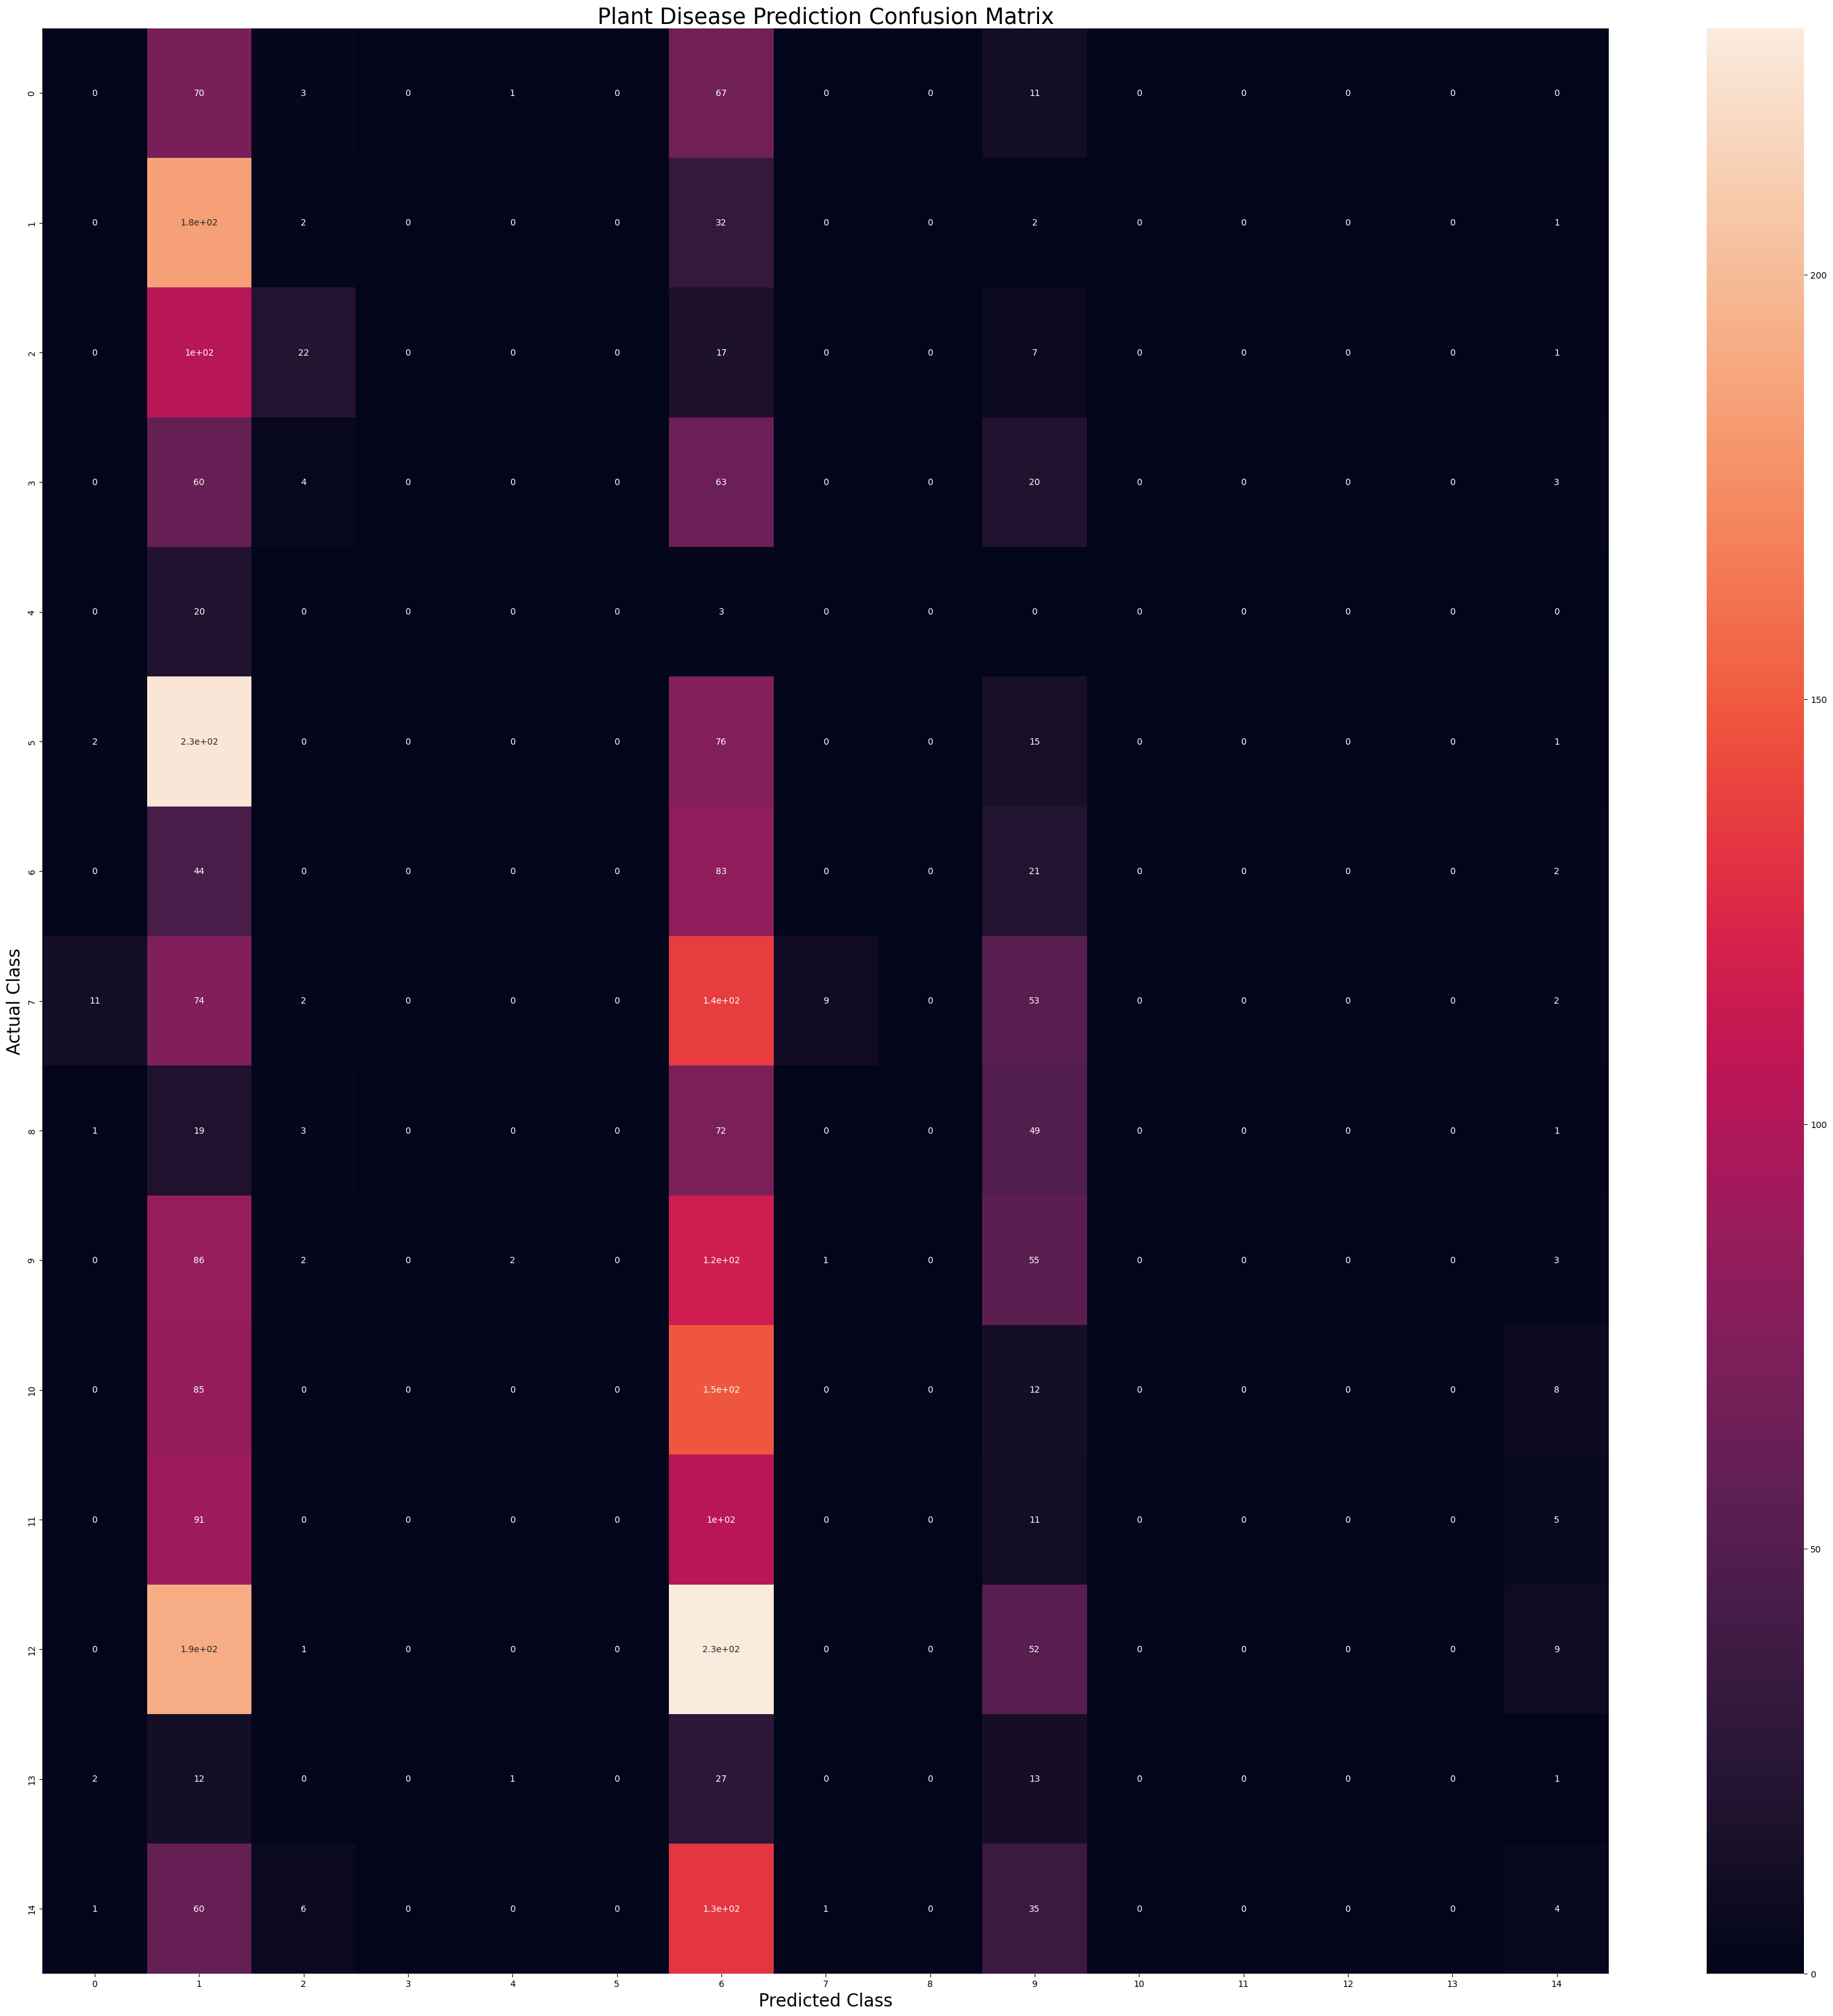

In [180]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel('Predicted Class',fontsize=20)
plt.ylabel('Actual Class',fontsize=20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize=25)
plt.show()

In [181]:

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [182]:
model=tf.keras.models.load_model('/content/Trained_Plant_Disease_Prediction.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [183]:

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,792 (9.88 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 165,905 (648.07 KB)

Using image: /content/PlantVillage_split/test/Pepper__bell___Bacterial_spot/de583596-e89f-4a21-be43-a6629318bd6e___NREC_B.Spot 1840.JPG


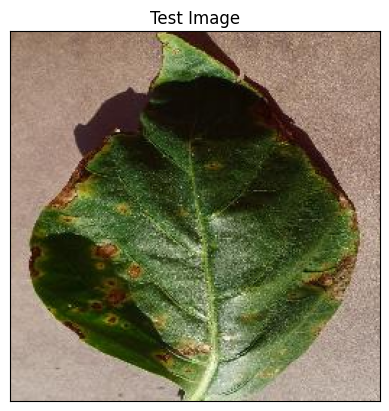

In [184]:
import cv2
import os

# Construct a valid image path from the TEST_DIR
# This assumes TEST_DIR and class_names are available from previous cells.

# Get a sample class name (e.g., the first one)
sample_class_name = class_names[0]

# Construct the path to that class within the test directory
class_test_dir = os.path.join(TEST_DIR, sample_class_name)

# Get the first image file from that class directory, if available
if os.path.exists(class_test_dir) and os.listdir(class_test_dir):
    sample_image_file = os.listdir(class_test_dir)[0]
    image_path = os.path.join(class_test_dir, sample_image_file)
    print(f"Using image: {image_path}")
else:
    print(f"No images found in {class_test_dir} or directory does not exist. Please check your TEST_DIR and dataset structure.")
    # Fallback or raise an error if no valid image can be found
    # For now, let's set a placeholder path which will likely cause the original error again if not found.
    image_path = ""


img=cv2.imread(image_path)

# Check if the image was loaded successfully before processing
if img is None:
    print(f"Error: Could not load image from {image_path}. Check if the file exists and is a valid image.")
else:
    #img=cv2.resize(img,(128,128))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title('Test Image')
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [185]:
image=tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr=tf.keras.preprocessing.image.img_to_array(image)
input_arr=np.array([input_arr]) #to convert single image to branch
print(input_arr.shape)

(1, 128, 128, 3)


In [186]:
prediction=model.predict(input_arr)
prediction.shape,prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


((1, 15),
 array([[3.3689067e-02, 3.4282309e-01, 9.0864524e-02, 8.2647073e-04,
         4.1756533e-02, 1.2662957e-06, 1.5491471e-01, 8.3209919e-03,
         6.8180717e-04, 1.7499432e-01, 5.2719315e-06, 4.3753331e-05,
         2.8472954e-05, 1.0926016e-03, 1.4995722e-01]], dtype=float32))

In [187]:
result_index=np.argmax(prediction)
result_index

np.int64(1)

In [188]:

class_names

['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

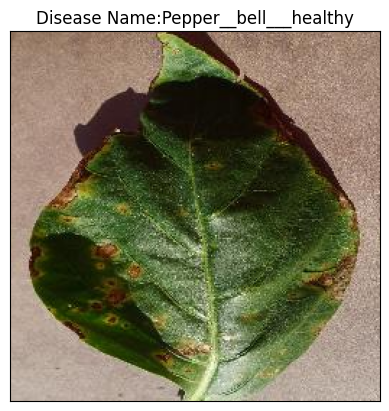

In [189]:
#Displaying Result of Disease Prediction
model_predicton=class_names[result_index]
plt.imshow(img)
plt.title(f"Disease Name:{model_predicton}")
plt.xticks([])
plt.yticks([])
plt.show()

In [190]:
model_predicton

'Pepper__bell___healthy'